# Support Vector Machines (SVM) para Clasificación Médica
En este notebook implementaremos un flujo completo de Data Science para clasificar tumores (Malignos vs. Benignos) utilizando el dataset *Wisconsin Breast Cancer*. 

El objetivo es entender cómo aplicar **SVC (Support Vector Classifier)**, la importancia crítica del escalado de variables, cómo interpretar los vectores de soporte y cómo optimizar el modelo mediante la búsqueda de hiperparámetros (`GridSearchCV`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuración de gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Carga y Exploración Inicial del Dataset (EDA)
Vamos a cargar los datos y echar un vistazo a la distribución de nuestra variable objetivo (clase) y a la colinealidad de algunas variables médicas continuas.

In [3]:
cancer_data = load_breast_cancer()

df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df["target"] = cancer_data.target 

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

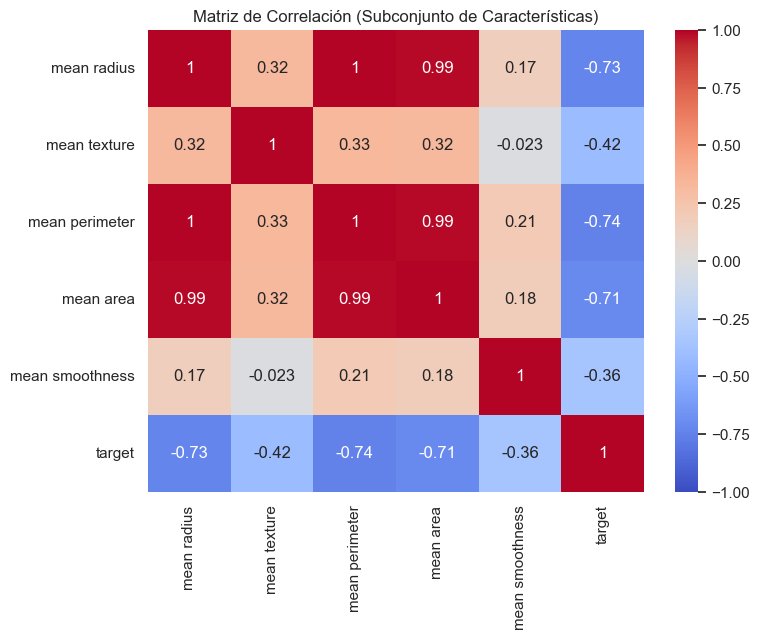

In [7]:
# Visualización de la colinealidad en un subconjunto de variables clave
features_interes = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'target']

plt.figure(figsize=(8, 6))
sns.heatmap(df[features_interes].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlación (Subconjunto de Características)")
plt.show()

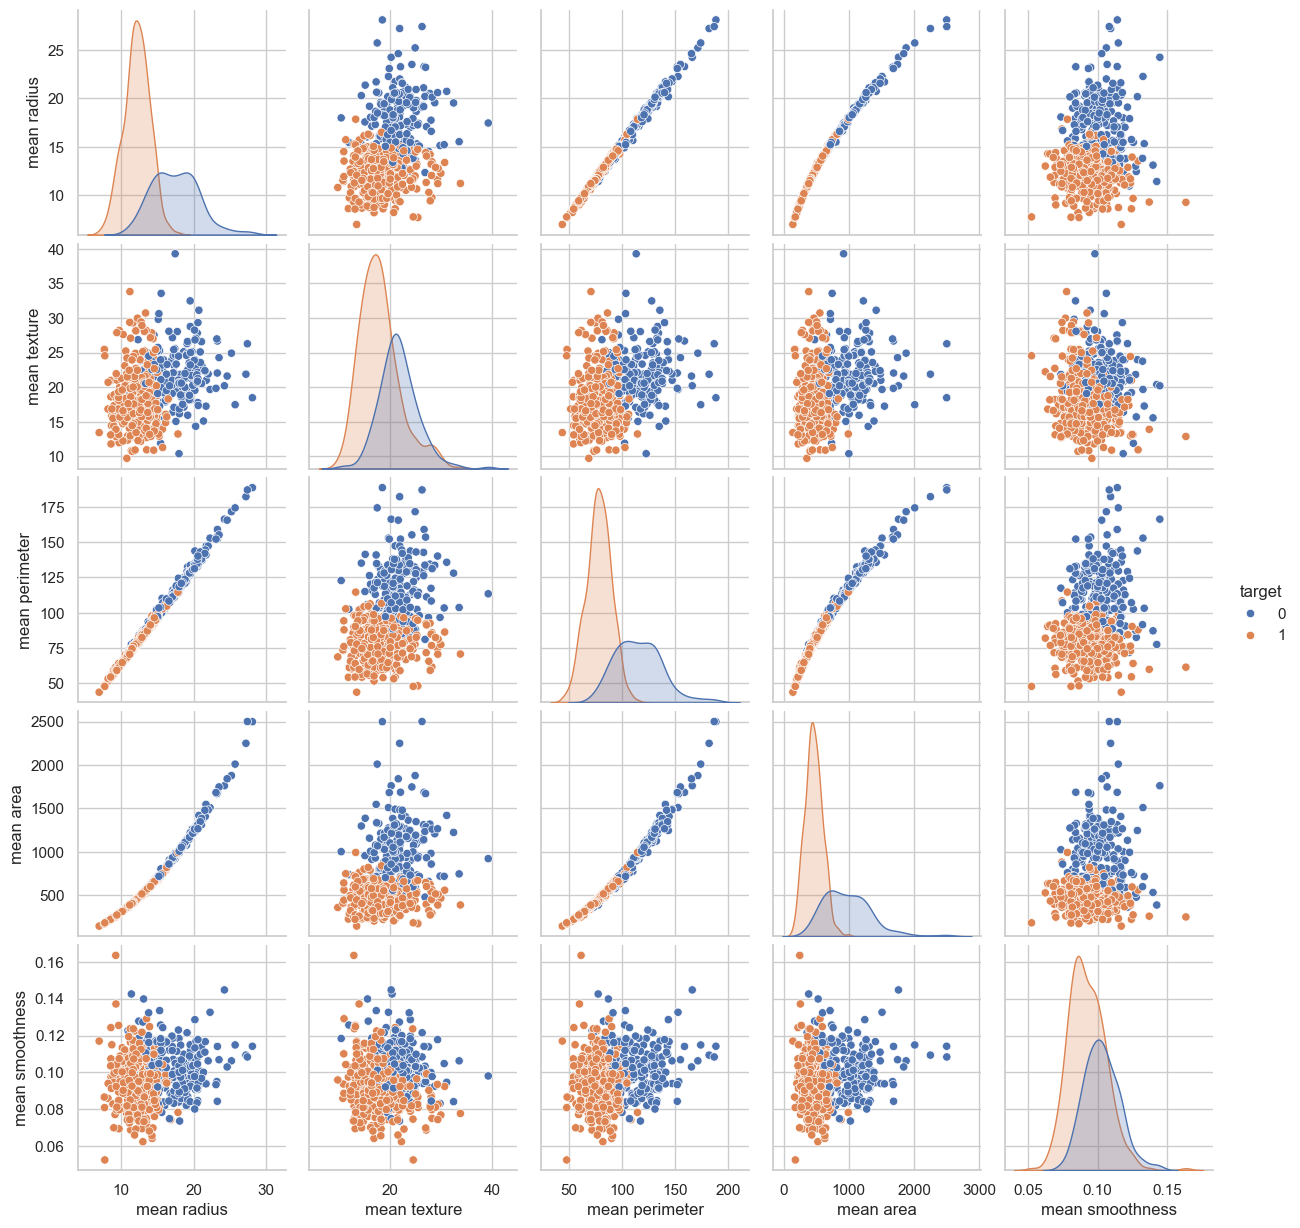

In [9]:
sns.pairplot(df[features_interes], hue="target")

## 2. Preparación de los Datos y Escalado
**Regla de Oro en SVM:** Dado que este algoritmo calcula distancias euclidianas para trazar el hiperplano y maximizar el margen, **todas las variables deben estar en la misma escala**. Si dejamos variables con rangos de miles (como `mean area`) junto a otras con decimales pequeños (como `mean smoothness`), el modelo se sesgará por completo.

In [ ]:
X = df.drop(columns= "target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, 
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.")
print(f"Media aproximada tras escalado (Train): {X_train_scaled.mean(axis=0)[0]:.2f}")
print(f"Desviación estándar tras escalado (Train): {X_train_scaled.std(axis=0)[0]:.2f}")

Datos escalados correctamente.
Media aproximada tras escalado (Train): -0.00
Desviación estándar tras escalado (Train): 1.00


## 3. Modelo Base (SVM Lineal y RBF)
Vamos a entrenar un modelo rápido usando un kernel RBF por defecto y analizaremos cuántos puntos se han convertido en **Vectores de Soporte**.

In [13]:
modelo_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_base.fit(X_train_scaled, y_train)

score_train = modelo_base.score(X_train_scaled, y_train)
score_test = modelo_base.score(X_test_scaled, y_test)

print(f"Precisión (Accuracy) en Entrenamiento: {score_train * 100:.2f}%")
print(f"Precisión (Accuracy) en Test: {score_test * 100:.2f}%")

Precisión (Accuracy) en Entrenamiento: 98.74%
Precisión (Accuracy) en Test: 97.66%


In [14]:
print(f"Número total de Vectores de Soporte seleccionados: {len(modelo_base.support_)}")
print(f"Vectores de soporte por clase (Clase 0 y Clase 1): {modelo_base.n_support_}")

print("\nCoordenadas de los primeros 3 vectores de soporte:")
print(modelo_base.support_vectors_[:3, :4])

Número total de Vectores de Soporte seleccionados: 97
Vectores de soporte por clase (Clase 0 y Clase 1): [49 48]

Coordenadas de los primeros 3 vectores de soporte:
[[ 0.89880086  0.92683207  0.77264817  0.76260663]
 [ 0.54765391 -0.26353759  0.52943942  0.42751958]
 [-0.13198535  0.39698689 -0.08476574 -0.22842517]]


## 4. Optimización de Hiperparámetros (`GridSearchCV`)
En lugar de probar parámetros a ojo, usaremos una búsqueda en rejilla con validación cruzada (`K-Fold = 5`) para testear diferentes combinaciones de:
* **`C`**: Tolerancia al error (Regularización).
* **`gamma`**: Radio de influencia de los vectores de soporte.
* **`kernel`**: La función de transformación espacial (`linear` o `rbf`).

In [15]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Mejor combinación de parámetros: {grid_search.best_params_}")
print(f"Mejor Score de validación cruzada: {grid_search.best_score_ * 100:.2f}%")

Mejor combinación de parámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor Score de validación cruzada: 97.48%


## 5. Evaluación Final del Modelo Optimizado
Utilizaremos el mejor modelo encontrado por la búsqueda automática (`grid_search.best_estimator_`) para realizar las predicciones definitivas sobre el conjunto de test independiente.

In [16]:
mejor_modelo_svm = grid_search.best_estimator_

y_pred = mejor_modelo_svm.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN DETALLADO ---")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

--- INFORME DE CLASIFICACIÓN DETALLADO ---
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        63
      benign       0.98      0.99      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



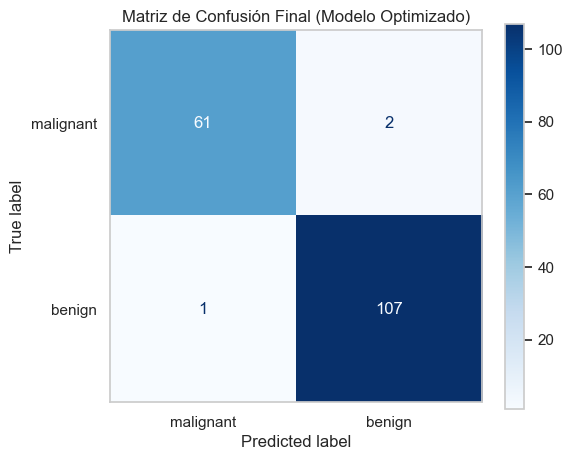

In [21]:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer_data.target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusión Final (Modelo Optimizado)")
plt.grid(False)
plt.show()